# **Clustring (KMeans)**

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
df = pd.read_csv("Preprocessed_dataset.csv")

## Select numeric features for clustring

In [12]:
feature = ["age", "educational-num", "hours-per-week", "capital-gain", "capital-loss"]
X = df[feature]

## Standardize the data

In [13]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Try different K values and record scores

In [14]:
inertias = []
silhouette_scores = []
k_values = [2,3,4,5,6]

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    score = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_scores.append(score)
    print(f"K={k} | Inertia = {kmeans.inertia_:.2f} | Silhouette = {score:.3f}")

K=2 | Inertia = 62706.43 | Silhouette = 0.814
K=3 | Inertia = 51700.18 | Silhouette = 0.245
K=4 | Inertia = 43066.76 | Silhouette = 0.252
K=5 | Inertia = 29420.68 | Silhouette = 0.299
K=6 | Inertia = 25530.55 | Silhouette = 0.307


## Plot the Elbow curve

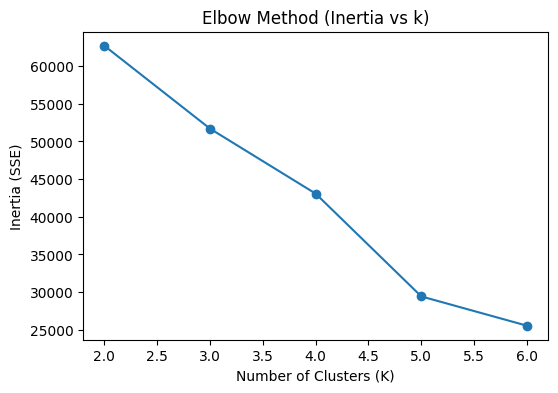

In [15]:
plt.figure(figsize=(6, 4))
plt.plot(k_values, inertias, marker='o')
plt.title('Elbow Method (Inertia vs k)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (SSE)')
plt.show()

## Plot the Silhouette scores

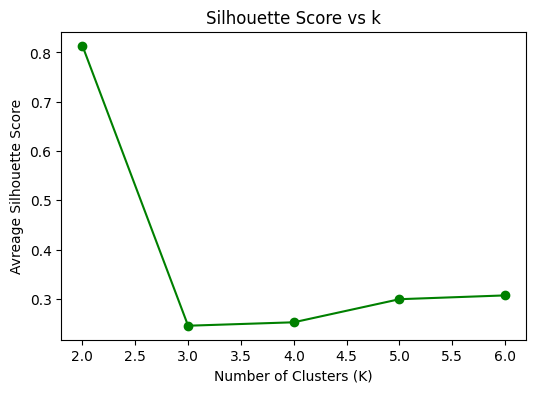

In [16]:
plt.figure(figsize=(6, 4))
plt.plot(k_values, silhouette_scores, marker='o', color='green')
plt.title('Silhouette Score vs k')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Avreage Silhouette Score')
plt.show()


## Choose the best K

In [19]:
best_k = 3
Kmeans_final = KMeans(n_clusters=best_k, random_state=42)
clusters = Kmeans_final.fit_predict(X_scaled)

# Align df with X_scaled by dropping the same rows
df_aligned = df.dropna(subset=feature)

df_aligned['Cluster']= clusters

/tmp/ipython-input-968862576.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_aligned['Cluster']= clusters


## Visualize clusters

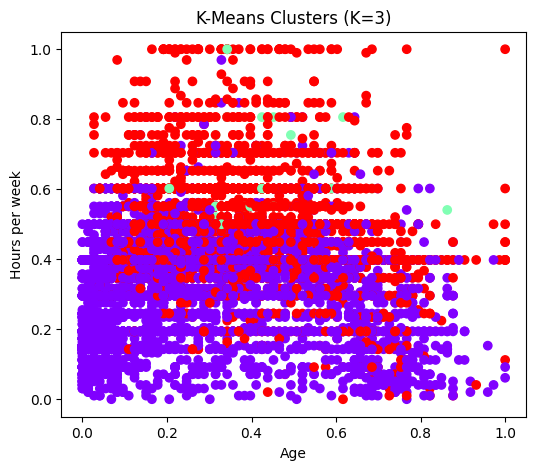

In [25]:
plt.figure(figsize=(6, 5))
plt.scatter(df_aligned["age"], df_aligned["hours-per-week"], c=df_aligned["Cluster"], cmap="rainbow")
plt.title(f"K-Means Clusters (K={best_k})")
plt.xlabel("Age")
plt.ylabel("Hours per week")
plt.show()

## Check cluster centers

In [26]:
centers = pd.DataFrame(scaler.inverse_transform(Kmeans_final.cluster_centers_), columns=feature)
print('Cluster Centers (approximte values):')
print(centers)

Cluster Centers (approximte values):
        age  educational-num  hours-per-week  capital-gain  capital-loss
0  0.267590         8.766461        0.359515      0.002648  1.720886e-03
1  0.410452        13.197531        0.518519      1.000000  3.469447e-18
2  0.348806        12.235108        0.471638      0.010600  5.161360e-02


# **K-Means Clustring Results**

We have applied the K-Means algoritm using different K values (2-6) to find natural grouings in the dataset. The **Elbow curve** showed a clear bend around k = 3, and the **Silhouette score** reached it's highest point at the same value, which means that 3 clusters gives the best separeation and cohesion.

Each cluster represent a group of adults similar characteristics:


*   **Cluster 0**: Yongers individuals with lower working hours and minimal capital gains.

*   **cluster 1:** Middle aged adults with average educationa and moderate income activity.
*   **cluster 2**: Older or more experienced individuals with higher capital gains and longer working hours.

This unsupervised clustring helps reveal hidden patterns that align with income categories, and provids insights into socioeconomic groups even without using the income label.




